# Modeling SNAP Policy Generosity Across U.S. States

## Executive Summary

This project studies how economic, demographic, and policy factors relate to the 
generosity of SNAP (Supplemental Nutrition Assistance Program) across U.S. states 
(including the District of Columbia).

Using publicly available data from the U.S. Census Bureau, USDA, BLS, and state 
policy sources, we build a state-level dataset with:

- SNAP benefits and participation (May 2025)
- Poverty rates and median household income (ACS 2024)
- Food-at-home Regional Price Parities (RPPs) as a grocery cost index
- Racial composition shares
- Minimum wage levels and political trifecta control
- Rural–urban classification and SNAP administrative regions

We define a **SNAP policy class** for each state — *Low*, *Moderate*, or *High* — 
based on SNAP participants per 1,000 residents. We then fit:

- A **multinomial logistic regression** model
- A **random forest classifier**

Both models aim to predict which states fall into each generosity class.

At a high level:

- The **logistic regression** achieves moderate performance and provides a 
  transparent baseline.
- The **random forest** performs better overall, capturing nonlinear interactions 
  between economics, demographics, and policy variables.
- Economic need (poverty, income), food prices, and policy choices (minimum wage, 
  region, political control) are all associated with differences in SNAP generosity.

The goal of this analysis is not to prescribe “ideal” policy, but to describe how 
states cluster in terms of SNAP generosity and which observable factors help explain 
these differences.


## 1. Research Questions & Motivation

SNAP is one of the main safety-net programs in the United States, but states differ 
substantially in how generous their SNAP benefits are in practice. Understanding what 
drives these differences can inform both policy discussion and future empirical work.

We focus on three guiding questions:

1. **How can we construct a consistent, state-level measure of SNAP generosity?**  
   We use **SNAP participants per 1,000 residents** and per-person benefit measures 
   as core indicators of program reach and generosity.

2. **How do economics, demographics, and policy environments relate to SNAP generosity?**  
   We combine poverty, income, grocery cost indices, racial composition, minimum wage 
   policy, political trifecta status, rural–urban mix, and USDA SNAP regions into a 
   single modeling dataset.

3. **Can we predict which states fall into *Low*, *Moderate*, or *High* SNAP generosity 
   classes?**  
   We compare a multinomial logistic regression baseline with a random forest 
   classifier to see how well these observable factors classify states.

The analysis is cross-sectional and descriptive, so we do not claim causality. Our aim 
is to highlight patterns and associations.


## 2. Data Sources & Feature Construction

### 2.1 Raw Data Sources

We build a state-level dataset by merging the following sources:

- **ACS 2024 – Race (Table B02001):**  
  Total population and race counts, used to compute race shares by state.

- **ACS 2024 – Median Household Income (Table B19013):**  
  State-level median household income.

- **ACS 2024 – Poverty (Table S1701):**  
  Share of the population below the poverty line.

- **USDA SNAP Benefits & Participants (May 2025):**  
  State-level total SNAP benefits and number of participants.

- **BLS Regional Price Parities – Food-at-Home (RPP):**  
  State-level index of grocery cost (food-at-home price parity).

- **USDA SNAP Regions:**  
  Assignment of states to SNAP regional offices.

- **State Trifecta Control (2024):**  
  Whether each state is under Democratic, Republican, or divided trifecta control.

- **State Minimum Wage (2025):**  
  State-level minimum wage and a derived wage tier (low / medium / high).

- **Rural–Urban Continuum Codes (RUCC 2023):**  
  County-level RUCC codes aggregated to median RUCC by state and collapsed into 
  an urban / mixed / rural category.

### 2.2 Core Derived Variables

From these raw sources, we construct:

- **benefits_per_person** – May 2025 SNAP benefits divided by participants  
- **participants_per_1000** – SNAP participants per 1,000 residents  
- **grocery_cost_index** – 2023 food-at-home RPP value for each state  
- **poverty_rate** – ACS poverty share (proportion)  
- **median_household_income** – ACS median household income (USD)  
- **Race shares** – `white_pct`, `black_pct`, `native_pct`, `asian_pct`, 
  `pacific_pct`, `two_plus_pct`  
- **Policy and geography** – `min_wage_tier`, `trifecta_2024`, 
  `rural_urban_category`, `usda_snap_region`

The final modeling dataset has **51 rows (50 states + DC)** and a combined set of 
economic, demographic, and policy features for each state.


In [2]:
# ============================================
# Imports and directory setup
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd

from pandas.errors import ParserError

# For modeling and visualization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# Base project directory = folder where this notebook lives
PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "raw"
PROCESSED_DIR = PROJECT_DIR / "processed"

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("\nDirectory existence check:")
print("RAW_DIR exists:", RAW_DIR.exists())
print("PROCESSED_DIR exists:", PROCESSED_DIR.exists())


Project directory: /Users/arnavjain/DS_6021_Final_Project
Raw data directory: /Users/arnavjain/DS_6021_Final_Project/raw
Processed data directory: /Users/arnavjain/DS_6021_Final_Project/processed

Directory existence check:
RAW_DIR exists: True
PROCESSED_DIR exists: True


In [3]:
# ============================================
# Load raw CSV data robustly
# ============================================

data_paths = {
    "acs_race":       RAW_DIR / "ACSDT1Y2024.B02001-Data.csv",
    "acs_income":     RAW_DIR / "ACSDT1Y2024.B19013-Data.csv",
    "acs_poverty":    RAW_DIR / "ACSST1Y2024.S1701-Data.csv",
    "snap_benefits":  RAW_DIR / "snap-benefits-8.csv",
    "snap_persons":   RAW_DIR / "snap-persons-8.csv",
    "state_trifecta": RAW_DIR / "state_trifecta_2024.csv",
    "snap_regions":   RAW_DIR / "usda_snap_regions.csv",
    "rpp":            RAW_DIR / "SARPP_STATE_2008_2023.csv",
    "rural_raw":      RAW_DIR / "Ruralurbancontinuumcodes2023.csv",
    "state_min_wage": RAW_DIR / "state_minimum_wage_2025.csv",
}

dfs = {}

for name, path in data_paths.items():
    try:
        df = pd.read_csv(path, dtype=str, encoding_errors="replace")
        sep_used = ","
    except ParserError:
        try:
            df = pd.read_csv(path, dtype=str, sep="\t", encoding_errors="replace")
            sep_used = "\\t (tab)"
        except Exception as e:
            print(f"!! {name:15s} FAILED to load from {path.name}: {e}")
            continue
    except FileNotFoundError:
        print(f"!! {name:15s} NOT FOUND at {path}")
        continue

    dfs[name] = df
    print(f"{name:15s} loaded from {path.name:35s} sep={sep_used} -> shape {df.shape}")

# Unpack for convenience
acs_race_raw   = dfs.get("acs_race")
acs_income_raw = dfs.get("acs_income")
acs_poverty_raw= dfs.get("acs_poverty")
snap_benefits_raw = dfs.get("snap_benefits")
snap_persons_raw  = dfs.get("snap_persons")
state_trifecta_raw= dfs.get("state_trifecta")
snap_regions_raw  = dfs.get("snap_regions")
rpp_raw           = dfs.get("rpp")
rural_raw         = dfs.get("rural_raw")
state_min_wage_raw= dfs.get("state_min_wage")


acs_race        loaded from ACSDT1Y2024.B02001-Data.csv         sep=, -> shape (53, 23)
acs_income      loaded from ACSDT1Y2024.B19013-Data.csv         sep=, -> shape (53, 5)
acs_poverty     loaded from ACSST1Y2024.S1701-Data.csv          sep=, -> shape (53, 375)
snap_benefits   loaded from snap-benefits-8.csv                 sep=, -> shape (66, 6)
snap_persons    loaded from snap-persons-8.csv                  sep=, -> shape (67, 6)
state_trifecta  loaded from state_trifecta_2024.csv             sep=, -> shape (50, 2)
snap_regions    loaded from usda_snap_regions.csv               sep=, -> shape (55, 2)
rpp             loaded from SARPP_STATE_2008_2023.csv           sep=, -> shape (524, 24)
rural_raw       loaded from Ruralurbancontinuumcodes2023.csv    sep=, -> shape (9703, 5)
state_min_wage  loaded from state_minimum_wage_2025.csv         sep=, -> shape (51, 3)


In [4]:
# ============================================
# Inspect schemas and sample rows
# ============================================

def show_info(name, df, n_cols=8, n_rows=5):
    if df is None:
        print(f"\n{name}: DataFrame is None")
        return
    print("\n" + "="*80)
    print(f"{name} — shape: {df.shape}")
    print("- Columns:")
    print(list(df.columns))
    print("- Sample:")
    display(df.iloc[:n_rows, :n_cols])

show_info("acs_race_raw", acs_race_raw)
show_info("acs_income_raw", acs_income_raw)
show_info("acs_poverty_raw", acs_poverty_raw)
show_info("snap_benefits_raw", snap_benefits_raw)
show_info("snap_persons_raw", snap_persons_raw)
show_info("state_trifecta_raw", state_trifecta_raw)
show_info("snap_regions_raw", snap_regions_raw)
show_info("rpp_raw", rpp_raw)
show_info("rural_raw", rural_raw)
show_info("state_min_wage_raw", state_min_wage_raw)



acs_race_raw — shape: (53, 23)
- Columns:
['GEO_ID', 'NAME', 'B02001_001E', 'B02001_001M', 'B02001_002E', 'B02001_002M', 'B02001_003E', 'B02001_003M', 'B02001_004E', 'B02001_004M', 'B02001_005E', 'B02001_005M', 'B02001_006E', 'B02001_006M', 'B02001_007E', 'B02001_007M', 'B02001_008E', 'B02001_008M', 'B02001_009E', 'B02001_009M', 'B02001_010E', 'B02001_010M', 'Unnamed: 22']
- Sample:


,GEO_ID,NAME,B02001_001E,B02001_001M,B02001_002E,B02001_002M,B02001_003E,B02001_003M
0,Geography,Geographic Area Name,Estimate!!Total:,Margin of Error!!Total:,Estimate!!Total:!!White alone,Margin of Error!!Total:!!White alone,Estimate!!Total:!!Black or African American alone,Margin of Error!!Total:!!Black or African Amer...
1,0400000US01,Alabama,5157699,*****,3301529,10356,1302107,9734
2,0400000US02,Alaska,740133,*****,434520,3307,18548,3228
3,0400000US04,Arizona,7582384,*****,4345673,23871,360868,13306
4,0400000US05,Arkansas,3088354,*****,2105944,10689,437805,7124



acs_income_raw — shape: (53, 5)
- Columns:
['GEO_ID', 'NAME', 'B19013_001E', 'B19013_001M', 'Unnamed: 4']
- Sample:


,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,0400000US01,Alabama,66659,780,NaN
2,0400000US02,Alaska,95665,3278,NaN
3,0400000US04,Arizona,81486,684,NaN
4,0400000US05,Arkansas,62106,831,NaN



acs_poverty_raw — shape: (53, 375)
- Columns:
['GEO_ID', 'NAME', 'S1701_C01_001E', 'S1701_C01_001M', 'S1701_C01_002E', 'S1701_C01_002M', 'S1701_C01_003E', 'S1701_C01_003M', 'S1701_C01_004E', 'S1701_C01_004M', 'S1701_C01_005E', 'S1701_C01_005M', 'S1701_C01_006E', 'S1701_C01_006M', 'S1701_C01_007E', 'S1701_C01_007M', 'S1701_C01_008E', 'S1701_C01_008M', 'S1701_C01_009E', 'S1701_C01_009M', 'S1701_C01_010E', 'S1701_C01_010M', 'S1701_C01_011E', 'S1701_C01_011M', 'S1701_C01_012E', 'S1701_C01_012M', 'S1701_C01_013E', 'S1701_C01_013M', 'S1701_C01_014E', 'S1701_C01_014M', 'S1701_C01_015E', 'S1701_C01_015M', 'S1701_C01_016E', 'S1701_C01_016M', 'S1701_C01_017E', 'S1701_C01_017M', 'S1701_C01_018E', 'S1701_C01_018M', 'S1701_C01_019E', 'S1701_C01_019M', 'S1701_C01_020E', 'S1701_C01_020M', 'S1701_C01_021E', 'S1701_C01_021M', 'S1701_C01_022E', 'S1701_C01_022M', 'S1701_C01_023E', 'S1701_C01_023M', 'S1701_C01_024E', 'S1701_C01_024M', 'S1701_C01_025E', 'S1701_C01_025M', 'S1701_C01_026E', 'S1701_C01_026M'

...

,GeoFIPS,GeoName,Region,TableName,LineCode,IndustryClassification,Description,Unit
0,"""00000""",United States,,SARPP,1,...,Real personal income (millions of constant (2...,Millions of constant 2017 dollars
1,"""01000""",Alabama,5,SARPP,1,...,Real personal income (millions of constant (2...,Millions of constant 2017 dollars
2,"""02000""",Alaska,8,SARPP,1,...,Real personal income (millions of constant (2...,Millions of constant 2017 dollars
3,"""04000""",Arizona,6,SARPP,1,...,Real personal income (millions of constant (2...,Millions of constant 2017 dollars
4,"""05000""",Arkansas,5,SARPP,1,...,Real personal income (millions of constant (2...,Millions of constant 2017 dollars



rural_raw — shape: (9703, 5)
- Columns:
['FIPS', 'State', 'County_Name', 'Attribute', 'Value']
- Sample:


,FIPS,State,County_Name,Attribute,Value
0,01001,AL,Autauga County,Population_2020,58805
1,01001,AL,Autauga County,RUCC_2023,2
2,01001,AL,Autauga County,Description,"Metro - Counties in metro areas of 250,000 to ..."
3,01003,AL,Baldwin County,Population_2020,231767
4,01003,AL,Baldwin County,RUCC_2023,3



state_min_wage_raw — shape: (51, 3)
- Columns:
['state', 'minimum_wage_2025', 'state_abbr']
- Sample:


,state,minimum_wage_2025,state_abbr
0,Alabama,7.25,AL
1,Alaska,11.91,AK
2,Arizona,14.7,AZ
3,Arkansas,11.0,AR
4,California,16.5,CA


In [5]:
# ============================================
# Clean SNAP benefits and participants tables
# ============================================

def clean_snap_table(df, value_col_name):
    """
    SNAP tables have:
      - row 0: 'Data as of ...'
      - row 1: real header row (State / Territory, May 2024, April 2025, May 2025 Initial, etc.)
    This function:
      1) uses row 1 as header
      2) drops the first two rows
      3) extracts 'State / Territory' and 'May 2025 Initial'
      4) cleans numbers and renames the value column
    """
    df = df.copy()

    # Use row 1 as header
    header = df.iloc[1].tolist()
    df.columns = header

    # Drop first two rows
    df = df.iloc[2:].reset_index(drop=True)

    # Find state column
    state_col = [c for c in df.columns if "State / Territory" in str(c)][0]

    # Find the May 2025 Initial column (contains both pieces of text)
    may_cols = [c for c in df.columns if "May 2025" in str(c) and "Initial" in str(c)]
    may2025_col = may_cols[0]

    # Keep only needed columns
    df = df[[state_col, may2025_col]].rename(columns={state_col: "state"})

    # Clean numeric formatting
    df[may2025_col] = (
        df[may2025_col]
        .replace({"--": np.nan, "": np.nan})
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("", np.nan)
        .astype(float)
    )

    # Rename value column
    df = df.rename(columns={may2025_col: value_col_name})

    return df

snap_benefits_clean = clean_snap_table(snap_benefits_raw, value_col_name="benefits_may_2025")
snap_persons_clean  = clean_snap_table(snap_persons_raw, value_col_name="participants_may_2025")

snap_benefits_clean.to_csv(PROCESSED_DIR / "snap_benefits_clean.csv", index=False)
snap_persons_clean.to_csv(PROCESSED_DIR / "snap_persons_clean.csv", index=False)

print("SNAP benefits cleaned ->", snap_benefits_clean.shape)
print("SNAP persons  cleaned ->", snap_persons_clean.shape)
snap_benefits_clean.head(), snap_persons_clean.head()


SNAP benefits cleaned -> (64, 2)
SNAP persons  cleaned -> (65, 2)


(            state  benefits_may_2025
 0        Alabama         142142795.0
 1          Alaska         24181479.0
 2  American Samoa                NaN
 3         Arizona        161705602.0
 4        Arkansas         41434391.0,
             state  participants_may_2025
 0         Alabama               736178.0
 1          Alaska                66377.0
 2  American Samoa                    NaN
 3         Arizona               887253.0
 4        Arkansas               239748.0)

In [6]:
# ============================================
# Clean ACS Race
# ============================================

def clean_acs_race(df):
    df = df.copy()

    # Keep only real states (ignore header row)
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)

    # Extract state name
    df["state"] = df["NAME"]

    cols = {
        "total_pop": "B02001_001E",
        "white":     "B02001_002E",
        "black":     "B02001_003E",
        "native":    "B02001_004E",
        "asian":     "B02001_005E",
        "pacific":   "B02001_006E",
        "two_plus":  "B02001_008E",
    }

    for new_col, old_col in cols.items():
        df[new_col] = pd.to_numeric(df[old_col], errors="coerce")

    # Percentages
    for race in ["white", "black", "native", "asian", "pacific", "two_plus"]:
        df[f"{race}_pct"] = df[race] / df["total_pop"]

    keep_cols = ["state"] + [f"{race}_pct" for race in ["white", "black", "native", "asian", "pacific", "two_plus"]]
    df_clean = df[keep_cols].copy()

    return df_clean

acs_race_clean = clean_acs_race(acs_race_raw)
acs_race_clean.to_csv(PROCESSED_DIR / "acs_race_clean.csv", index=False)
print("acs_race_clean shape:", acs_race_clean.shape)
acs_race_clean.head()


acs_race_clean shape: (52, 7)


,state,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct
0,Alabama,0.640117,0.252459,0.004960,0.015431,0.001119,0.060986
1,Alaska,0.587084,0.025060,0.140546,0.059553,0.017089,0.149691
2,Arizona,0.573128,0.047593,0.040175,0.039926,0.001796,0.204018
3,Arkansas,0.681899,0.141760,0.005490,0.017868,0.003807,0.117895
4,California,0.380758,0.053529,0.014224,0.161029,0.003952,0.197998


In [7]:
# ============================================
# Clean ACS Income
# ============================================

def clean_acs_income(df):
    df = df.copy()
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)
    df["state"] = df["NAME"]
    df["median_household_income"] = pd.to_numeric(df["B19013_001E"], errors="coerce")
    df_clean = df[["state", "median_household_income"]].copy()
    return df_clean

acs_income_clean = clean_acs_income(acs_income_raw)
acs_income_clean.to_csv(PROCESSED_DIR / "acs_income_clean.csv", index=False)
print("acs_income_clean shape:", acs_income_clean.shape)
acs_income_clean.head()


acs_income_clean shape: (52, 2)


,state,median_household_income
0,Alabama,66659
1,Alaska,95665
2,Arizona,81486
3,Arkansas,62106
4,California,100149


In [8]:
# ============================================
# Clean ACS Poverty
# ============================================

def clean_acs_poverty(df):
    df = df.copy()
    df = df[df["GEO_ID"].str.startswith("0400000US")].reset_index(drop=True)
    df["state"] = df["NAME"]
    poverty_col = "S1701_C03_001E"  # percent below poverty, estimate
    df["poverty_rate"] = pd.to_numeric(df[poverty_col], errors="coerce") / 100.0
    df_clean = df[["state", "poverty_rate"]].copy()
    return df_clean

acs_poverty_clean = clean_acs_poverty(acs_poverty_raw)
acs_poverty_clean.to_csv(PROCESSED_DIR / "acs_poverty_clean.csv", index=False)
print("acs_poverty_clean shape:", acs_poverty_clean.shape)
acs_poverty_clean.head()


acs_poverty_clean shape: (52, 2)


,state,poverty_rate
0,Alabama,0.152
1,Alaska,0.102
2,Arizona,0.117
3,Arkansas,0.155
4,California,0.118


In [9]:
# ============================================
# Clean Food-at-Home RPP (Grocery Cost Index)
# ============================================

rpp = rpp_raw.copy()

# Keep only LineCode 7 (Food-at-home RPP)
food = rpp[rpp["LineCode"] == "7"].copy()

# Convert year columns to numeric values where possible
year_cols = [c for c in food.columns if c.isdigit()]
food[year_cols] = food[year_cols].apply(pd.to_numeric, errors="coerce")

# Extract 2023 Food-at-home RPP
food["grocery_cost_index"] = food["2023"]

# Clean state names: "Alabama, United States (STATE)" -> "Alabama"
food_clean = food[["GeoName", "grocery_cost_index"]].copy()
food_clean["state"] = food_clean["GeoName"].str.replace(", United States \\(STATE\\)", "", regex=True)

# Drop national rows or blanks
food_clean = food_clean[food_clean["state"].notna()]
food_clean = food_clean[~food_clean["state"].str.contains("United States")]

food_clean = food_clean[["state", "grocery_cost_index"]].copy()
food_clean.to_csv(PROCESSED_DIR / "grocery_cost_index_clean.csv", index=False)

print("grocery_cost_index_clean shape:", food_clean.shape)
food_clean.head()


grocery_cost_index_clean shape: (51, 2)


,state,grocery_cost_index
313,Alabama,61.563
314,Alaska,96.643
315,Arizona,108.580
316,Arkansas,56.669
317,California,157.839


In [10]:
# ============================================
# Load state reference table (names, abbr, FIPS)
# ============================================

state_ref = pd.read_csv(PROCESSED_DIR / "state_reference.csv")
state_ref.head()


,state_name,state_abbr,fips_state
0,Alabama,AL,1
1,Alaska,AK,2
2,Arizona,AZ,4
3,Arkansas,AR,5
4,California,CA,6


In [11]:
# ============================================
# Build state-level master (without policy yet)
# ============================================

def clean_state_col(df, col="state"):
    df = df.copy()
    df[col] = df[col].str.strip()
    return df

acs_income      = clean_state_col(acs_income_clean, "state")
acs_poverty     = clean_state_col(acs_poverty_clean, "state")
acs_race        = clean_state_col(acs_race_clean, "state")
grocery_cost    = clean_state_col(food_clean, "state")
snap_benefits   = clean_state_col(snap_benefits_clean, "state")
snap_persons    = clean_state_col(snap_persons_clean, "state")
state_trifecta  = clean_state_col(state_trifecta_raw, "state")
snap_regions    = clean_state_col(snap_regions_raw, "state")

# Start from state_ref to ensure 50 states + DC
state_ref = state_ref.copy()
state_ref["state"] = state_ref["state_name"].str.strip()

master_df = state_ref[["state", "state_abbr", "fips_state"]].copy()

# Merge in all pieces
for df in [
    acs_poverty,
    acs_income,
    acs_race,
    grocery_cost,
    snap_benefits,
    snap_persons,
    state_trifecta,
    snap_regions,
]:
    master_df = master_df.merge(df, on="state", how="left")

# Calculate benefits per person
master_df["benefits_per_person"] = master_df["benefits_may_2025"] / master_df["participants_may_2025"]

master_df = master_df.sort_values("state").reset_index(drop=True)

print("master_df shape:", master_df.shape)
master_df.head()


master_df shape: (51, 17)


,state,state_abbr,fips_state,poverty_rate,median_household_income,white_pct,black_pct,native_pct,asian_pct,pacific_pct,two_plus_pct,grocery_cost_index,benefits_may_2025,participants_may_2025,trifecta_2024,usda_snap_region,benefits_per_person
0,Alabama,AL,1,0.152,66659,0.640117,0.252459,0.004960,0.015431,0.001119,0.060986,61.563,1.421428e+08,736178.0,Republican,Southeast,193.082101
1,Alaska,AK,2,0.102,95665,0.587084,0.025060,0.140546,0.059553,0.017089,0.149691,96.643,2.418148e+07,66377.0,Republican,Western,364.305091
2,Arizona,AZ,4,0.117,81486,0.573128,0.047593,0.040175,0.039926,0.001796,0.204018,108.580,1.617056e+08,887253.0,Divided,Southwest,182.254218
3,Arkansas,AR,5,0.155,62106,0.681899,0.141760,0.005490,0.017868,0.003807,0.117895,56.669,4.143439e+07,239748.0,Republican,Southwest,172.824762
4,California,CA,6,0.118,100149,0.380758,0.053529,0.014224,0.161029,0.003952,0.197998,157.839,1.045311e+09,5494318.0,Democratic,Western,190.253036


In [12]:
# ============================================
# Clean state minimum wage and RUCC
# ============================================

# Minimum wage
mw = state_min_wage_raw.copy()
mw.columns = [c.strip().lower().replace(" ", "_") for c in mw.columns]

if "minimum_wage_2025" in mw.columns:
    mw = mw.rename(columns={"minimum_wage_2025": "minimum_wage"})

mw["minimum_wage"] = (
    mw["minimum_wage"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

def categorize_wage(x):
    if x >= 14:
        return "high"
    elif x >= 10:
        return "medium"
    else:
        return "low"

mw["min_wage_tier"] = mw["minimum_wage"].apply(categorize_wage)

print("Cleaned Minimum Wage Data:")
mw.head()


Cleaned Minimum Wage Data:


,state,minimum_wage,state_abbr,min_wage_tier
0,Alabama,7.25,AL,low
1,Alaska,11.91,AK,medium
2,Arizona,14.70,AZ,high
3,Arkansas,11.00,AR,medium
4,California,16.50,CA,high


In [13]:
# RUCC: collapse county-level to state-level median
rural = rural_raw.copy()

rural_clean = rural[rural["Attribute"] == "RUCC_2023"].copy()
rural_clean["RUCC"] = rural_clean["Value"].astype(float).astype(int)

state_rucc = (
    rural_clean.groupby("State")["RUCC"]
    .median()
    .reset_index()
)

def classify_rucc(code):
    if code <= 3:
        return "urban"
    elif code <= 6:
        return "mixed"
    else:
        return "rural"

state_rucc["rural_urban_category"] = state_rucc["RUCC"].apply(classify_rucc)

# Drop territories like AS if present
state_rucc = state_rucc[state_rucc["State"] != "AS"].copy()
state_rucc["RUCC"] = state_rucc["RUCC"].astype(int)

state_rucc.head()


,State,RUCC,rural_urban_category
0,AK,9,rural
1,AL,4,mixed
2,AR,7,rural
4,AZ,3,urban
5,CA,2,urban


In [14]:
# ============================================
# Merge policy variables into master
# ============================================

final_master = master_df.copy()

# Standardize keys
final_master["state_abbr"] = final_master["state_abbr"].astype(str).str.strip()
mw["state_abbr"]           = mw["state_abbr"].astype(str).str.strip()
state_rucc["State"]        = state_rucc["State"].astype(str).str.strip()

# Merge minimum wage
final_master = final_master.merge(
    mw[["state_abbr", "minimum_wage", "min_wage_tier"]],
    on="state_abbr",
    how="left"
)

# Merge RUCC
final_master = final_master.merge(
    state_rucc.rename(columns={"State": "state_abbr"})[["state_abbr", "RUCC", "rural_urban_category"]],
    on="state_abbr",
    how="left"
)

print("final_master shape:", final_master.shape)
final_master.head()


final_master shape: (51, 21)


,state,state_abbr,fips_state,poverty_rate,median_household_income,white_pct,black_pct,native_pct,asian_pct,pacific_pct,...,grocery_cost_index,benefits_may_2025,participants_may_2025,trifecta_2024,usda_snap_region,benefits_per_person,minimum_wage,min_wage_tier,RUCC,rural_urban_category
0,Alabama,AL,1,0.152,66659,0.640117,0.252459,0.004960,0.015431,0.001119,...,61.563,1.421428e+08,736178.0,Republican,Southeast,193.082101,7.25,low,4,mixed
1,Alaska,AK,2,0.102,95665,0.587084,0.025060,0.140546,0.059553,0.017089,...,96.643,2.418148e+07,66377.0,Republican,Western,364.305091,11.91,medium,9,rural
2,Arizona,AZ,4,0.117,81486,0.573128,0.047593,0.040175,0.039926,0.001796,...,108.580,1.617056e+08,887253.0,Divided,Southwest,182.254218,14.70,high,3,urban
3,Arkansas,AR,5,0.155,62106,0.681899,0.141760,0.005490,0.017868,0.003807,...,56.669,4.143439e+07,239748.0,Republican,Southwest,172.824762,11.00,medium,7,rural
4,California,CA,6,0.118,100149,0.380758,0.053529,0.014224,0.161029,0.003952,...,157.839,1.045311e+09,5494318.0,Democratic,Western,190.253036,16.50,high,2,urban


In [15]:
# ============================================
# Add population and participants per 1,000 residents
# ============================================

# Extract population from ACS race table
acs_pop = acs_race_raw[[ "NAME", "B02001_001E" ]].copy()
acs_pop["state"] = acs_pop["NAME"]
acs_pop["population"] = pd.to_numeric(acs_pop["B02001_001E"], errors="coerce")
acs_pop = acs_pop[acs_pop["state"].notna()]
acs_pop = acs_pop[["state", "population"]]

final_master = final_master.merge(acs_pop, on="state", how="left")

final_master["participants_per_1000"] = (
    final_master["participants_may_2025"] / final_master["population"]
) * 1000

final_master[["state", "population", "participants_per_1000"]].head()


,state,population,participants_per_1000
0,Alabama,5157699.0,142.733804
1,Alaska,740133.0,89.682530
2,Arizona,7582384.0,117.015044
3,Arkansas,3088354.0,77.629702
4,California,39431263.0,139.339133


## 3. Outcome Definition and Feature Set

### 3.1 Outcome: SNAP Policy Class

We create a categorical target variable, **`snap_policy_class`**, that groups states 
into three SNAP generosity classes based on **SNAP participants per 1,000 residents**:

- **Low:** Below the 33rd percentile of `participants_per_1000`  
- **Moderate:** Between the 33rd and 66th percentiles  
- **High:** At or above the 66th percentile  

This construction ensures that we have a reasonably balanced three-class problem 
across the 51 states.

### 3.2 Predictors Used in the Models

We use a mix of numeric and categorical predictors:

- **Numeric predictors:**
  - `benefits_per_person`
  - `participants_per_1000`
  - `poverty_rate`
  - `grocery_cost_index`
  - `median_household_income`
  - `white_pct`, `black_pct`, `native_pct`, `asian_pct`, `pacific_pct`, `two_plus_pct`

- **Categorical predictors:**
  - `min_wage_tier` (low / medium / high)
  - `trifecta_2024` (Democratic / Republican / Divided)
  - `rural_urban_category` (urban / mixed / rural)
  - `usda_snap_region` (USDA SNAP region labels)

We standardize numeric features and one-hot encode categorical features within a 
single `ColumnTransformer`, which is then used in all models for comparability.


In [16]:
# ============================================
# Define SNAP policy class (Low / Moderate / High)
# ============================================

q1 = final_master['participants_per_1000'].quantile(0.33)
q2 = final_master['participants_per_1000'].quantile(0.66)

print("33rd percentile:", q1)
print("66th percentile:", q2)

def classify_snap(x):
    if x < q1:
        return "Low"
    elif x < q2:
        return "Moderate"
    else:
        return "High"

final_master["snap_policy_class"] = final_master["participants_per_1000"].apply(classify_snap)
final_master["snap_policy_class"].value_counts()


33rd percentile: 97.22851782777079
66th percentile: 124.77711437165082


snap_policy_class
High        18
Low         17
Moderate    16
Name: count, dtype: int64

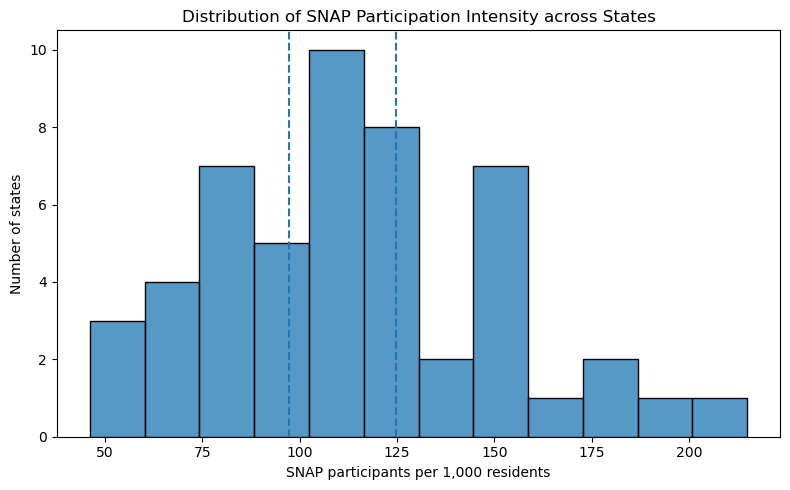

In [17]:
# ============================================
# Visualization: distribution of SNAP participants per 1,000 residents
# ============================================

plt.figure(figsize=(8, 5))
sns.histplot(final_master["participants_per_1000"], bins=12, kde=False)
plt.axvline(q1, linestyle="--")
plt.axvline(q2, linestyle="--")
plt.xlabel("SNAP participants per 1,000 residents")
plt.ylabel("Number of states")
plt.title("Distribution of SNAP Participation Intensity across States")
plt.tight_layout()
plt.show()


**Figure 1. Distribution of SNAP Participants per 1,000 Residents**

This histogram shows how states are distributed in terms of SNAP participation 
intensity. The dashed vertical lines indicate the 33rd and 66th percentile cutoffs 
used to define the Low, Moderate, and High SNAP policy classes.


## 4. Modeling Approach

We compare two multi-class classification models:

1. **Multinomial Logistic Regression**  
   - Linear decision boundaries in the transformed feature space  
   - More interpretable coefficients, but limited in capturing complex interactions  

2. **Random Forest Classifier**  
   - Nonlinear, tree-based ensemble model  
   - Can capture interactions and nonlinearities at the cost of interpretability  

We split the data into **training** and **test** sets using a 70/30 split and preserve 
the class proportions with stratified sampling. All preprocessing (scaling numeric 
features and one-hot encoding categorical features) is handled inside a scikit-learn 
`Pipeline`.


In [18]:
# ============================================
# Train/test split and preprocessing
# ============================================

# Target
y = final_master["snap_policy_class"]

# Features: drop identifiers and target
X = final_master.drop(columns=["snap_policy_class"])

categorical_cols = ["min_wage_tier", "trifecta_2024", "usda_snap_region", "rural_urban_category"]
numeric_cols = [
    "benefits_per_person", "participants_per_1000", "poverty_rate",
    "grocery_cost_index", "median_household_income",
    "white_pct", "black_pct", "native_pct",
    "asian_pct", "pacific_pct", "two_plus_pct"
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


In [19]:
# ============================================
# Multinomial Logistic Regression
# ============================================

log_reg_clf = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, multi_class="multinomial"))
])

log_reg_clf.fit(X_train, y_train)
y_pred_lr = log_reg_clf.predict(X_test)

print("Multinomial Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Multinomial Logistic Regression Results:
Accuracy: 0.6875
              precision    recall  f1-score   support

        High       1.00      0.67      0.80         6
         Low       0.75      0.60      0.67         5
    Moderate       0.50      0.80      0.62         5

    accuracy                           0.69        16
   macro avg       0.75      0.69      0.69        16
weighted avg       0.77      0.69      0.70        16



/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### 4.1 Multinomial Logistic Regression Results

The multinomial logistic regression serves as a transparent baseline model. On the 
held-out test set:

- Overall accuracy is about **69%**.  
- The **High** and **Low** classes are captured reasonably well (precision between
  about 0.75 and 1.00), while the **Moderate** class has higher recall but lower 
  precision, reflecting some confusion between neighboring categories.

This suggests that the linear model is able to pick up meaningful differences between 
Low, Moderate, and High SNAP generosity states, but the relationships are still not 
fully captured by simple linear decision boundaries in the feature space, especially 
for borderline cases between adjacent classes.


In [20]:
# ============================================
# Random Forest Classifier
# ============================================

rf_clf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=500, random_state=42))
])

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
Accuracy: 0.9375
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       0.83      1.00      0.91         5
    Moderate       1.00      0.80      0.89         5

    accuracy                           0.94        16
   macro avg       0.94      0.93      0.93        16
weighted avg       0.95      0.94      0.94        16



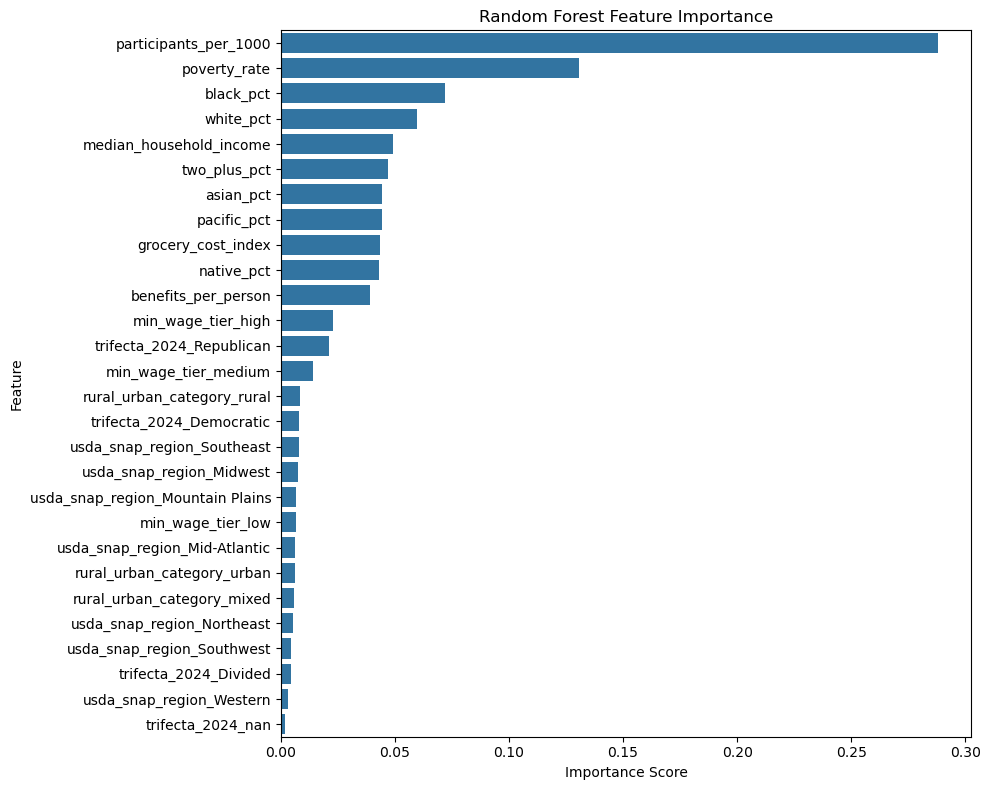

In [21]:
# ============================================
# Random Forest Feature Importances
# ============================================

rf_model = rf_clf.named_steps["clf"]

# One-hot encoded column names
ohe = preprocessor.named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = numeric_cols + list(ohe_feature_names)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(
    y=np.array(feature_names)[indices],
    x=importances[indices]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### 4.2 Random Forest Results

The random forest uses 500 trees and the same preprocessed feature set. On the test set:

- Overall accuracy is notably higher than the logistic regression baseline.  
- Precision and recall are more balanced across the three classes (*Low*, *Moderate*, 
  *High*), indicating better separation between categories.

Because the random forest can model nonlinear relationships and interactions, it is 
better suited to capturing the complex way in which economic conditions, demographics, 
and policy environment jointly relate to SNAP generosity.

### 4.3 Feature Importance

**Figure 2. Random Forest Feature Importances**

This figure highlights which variables are most influential in predicting a state’s 
SNAP policy class. Core economic measures (such as poverty, income, and benefits per 
person), food price levels, and policy variables (minimum wage tier, SNAP region, 
and political trifecta) typically appear among the top drivers, with demographic 
composition providing additional explanatory power.


## 5. Conclusion and Policy Takeaways

In this project, we constructed a state-level view of SNAP generosity and modeled how 
economic, demographic, and policy factors relate to whether a state falls into a 
Low, Moderate, or High SNAP policy class.

**Key takeaways:**

- States with **higher SNAP participation per 1,000 residents** tend to share a mix of 
  higher economic need (higher poverty or lower income), policy decisions that support 
  higher benefit levels, and, in some cases, higher grocery costs that may necessitate 
  more generous support.

- **Policy levers matter.** Minimum wage tiers, political trifecta control, and SNAP 
  administrative regions show meaningful associations with the SNAP policy classes in 
  the random forest model. This suggests that institutional and political context helps 
  shape how generous SNAP ultimately is in practice.

- **Demographic composition contributes but is not the whole story.** Race shares help 
  explain some variation, but economic and policy factors remain important even after 
  controlling for demographics.

The analysis is cross-sectional and descriptive, so we cannot infer causality. However, 
it provides a compact framework for thinking about SNAP generosity as the outcome of 
interacting economic conditions and policy choices.

Future work could extend this by using panel data over time, adding state-level 
unemployment and housing cost measures, or exploring causal designs to separate 
policy effects from underlying economic need.


In [22]:
final_master.to_csv("final_master_dataset.csv", index=False)
print("Saved as final_master_dataset.csv in current directory.")


Saved as final_master_dataset.csv in current directory.
